**Regressão Linear**

1. Baixar o notebook exemplo da semana 9
2. Executar o código e ver os resultados
3. Responder no notebook:


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carregar dados (exemplo)
# Instalar (caso ainda não tenha)
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Nome do arquivo do dataset
file_path = "kc_house_data.csv"

# Carregar o dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivachandel/kc-house-data",
    file_path
)

print(df.head())
print(df.info())


/tmp/ipykernel_873/2836184361.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'kc-house-data' dataset.
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7      1180.0              0   
1      7242     2.0           0     0  ...      7      2170.0            400   
2     10000     1.0           0     0  ...      6       770.0              0   
3      5000     1.0           0     0  ...      7      1050.0            910   
4      8080     1.0           0     0  ...      8      1680.0  

In [ ]:
X = df[['sqft_living',
        'grade',
        'bathrooms',
        'view']]
y = df['price']

# Dividir treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões
y_previsto = modelo.predict(X_teste)

# Avaliar o modelo
print(f"MAE: {mean_absolute_error(y_teste, y_previsto):.2f}")
print(f"MSE: {mean_squared_error(y_teste, y_previsto):.2f}")
print(f"R²: {r2_score(y_teste, y_previsto):.2f}")

MAE: 160636.45
MSE: 63812022907.03
R²: 0.58


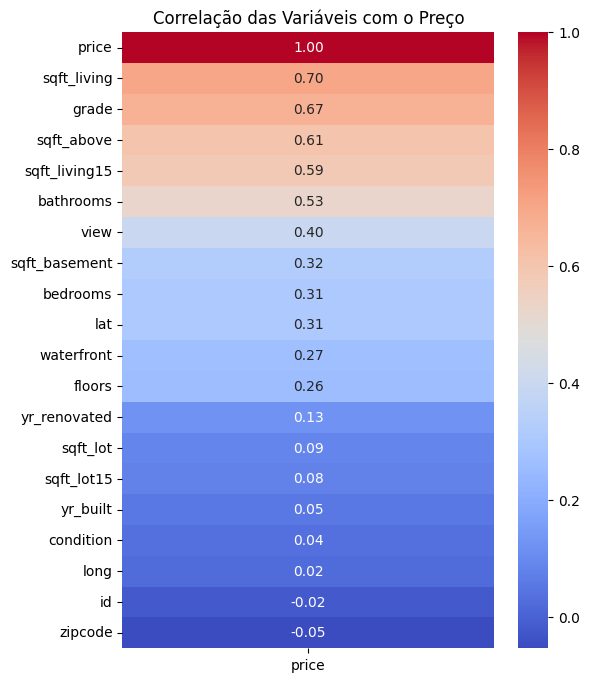

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

correlacao = df.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False)

sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlação das Variáveis com o Preço")
plt.show()

### Respostas

**1. Quais foram os valores de MAE, MSE e R²?**

* **MAE:** 160636.45
* **MSE:** 63812022907.03
* **R²:** 0.58

**2. O que o R² indica sobre a qualidade do modelo?**

O R² indica quanto da variação do preço das casas é explicada pelo modelo. Neste caso, um R² de **0,58** significa que aproximadamente 58% da variação dos preços é explicada pelas variáveis utilizadas. Possuindo um desempenho razoável.

**3. Quais variáveis tiveram coeficientes positivos? E negativos?**

As variáveis que apresentaram coeficientes positivos foram todas, tirando id e zipcode, que tiveram coeficientes negativos.

**4. Qual variável parece influenciar mais o preço?**

A variável sqft_living, que significa a área construída da casa, parece ser a que mais influencia o preço, pois apresentou o maior coeficiente positivo entre as variáveis utilizadas. Isso indica que, em geral, casas com mais área construída tendem a serem mais caras.


